<a href="https://colab.research.google.com/github/kamalrajarulprakasam-sudo/BronzeBadge_GenAIAssignments/blob/main/Problem1_EmployeeProductivityRegression/employee_productivity_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 1: Employee Productivity Prediction
## Multivariate Linear Regression

---
**Course:** L3-L5 Gen AI App Developer | Bronze Badge  
**Topic:** Supervised Learning — Regression  

### Problem Statement
A company wants to **predict employee productivity scores** to improve workforce planning and training programs.  
Build a **multivariate linear regression model** that predicts an employee's **Productivity Score** based on work-related factors.

### Feature Description
| Feature | Type | Description |
|---------|------|-------------|
| Experience (yrs) | Numeric | Years of professional experience |
| Training Hours | Numeric | Total hours of training completed |
| Working Hours | Numeric | Average weekly working hours |
| Projects | Numeric | Number of active/completed projects |

### Target Variable
**Productivity Score** — Continuous value (50–100), higher = more productive

### Regression Equation
`Productivity = β0 + β1×Experience + β2×TrainingHours + β3×WorkingHours + β4×Projects + ε`

In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import numpy as np                    # numpy  → numerical computations, array operations
import pandas as pd                   # pandas → tabular data manipulation (DataFrame)
import matplotlib.pyplot as plt       # matplotlib → base plotting library
import seaborn as sns                 # seaborn → statistical visualization on top of matplotlib

from sklearn.linear_model import LinearRegression          # Linear Regression algorithm
from sklearn.model_selection import train_test_split       # Split dataset into train/test
from sklearn.model_selection import cross_val_score        # K-Fold Cross Validation
from sklearn.metrics import mean_squared_error             # MSE: average squared error
from sklearn.metrics import r2_score                       # R²: variance explained by model
from sklearn.metrics import mean_absolute_error            # MAE: average absolute error
from sklearn.preprocessing import StandardScaler           # Feature scaling (zero mean, unit variance)

import warnings
warnings.filterwarnings('ignore')     # Suppress non-critical deprecation warnings

# Set consistent plot style
try:
    plt.style.use('seaborn-v0_8')     # Works in matplotlib >= 3.6
except:
    plt.style.use('seaborn')          # Fallback for older matplotlib versions

sns.set_palette('husl')               # Use HSL color palette (vivid and distinct colors)

print('Step 1 COMPLETE: All libraries imported successfully!')
print(f'  numpy    version: {np.__version__}')
print(f'  pandas   version: {pd.__version__}')
import sklearn
print(f'  sklearn  version: {sklearn.__version__}')

Step 1 COMPLETE: All libraries imported successfully!
  numpy    version: 2.0.2
  pandas   version: 2.2.2
  sklearn  version: 1.6.1


In [2]:
# ============================================================
# STEP 2: Create Extended Employee Productivity Dataset
# ============================================================
# Original dataset: 10 records (from problem statement)
# Extended dataset: 30 records (added 20 extra realistic records)
# Reason: More data → better model training and more reliable evaluation

data = {
    # Feature 1: Years of work experience (1–15 years range)
    'Experience': [
         2,  5,  1,  8,  4, 10,  3,  6,  7,  2,   # Original 10 records
         9, 11,  3,  7,  4,  6,  5,  8,  1, 12,   # Extended records (10-20)
        15,  6,  3,  9,  2,  7,  4, 13,  8,  5    # Extended records (21-30)
    ],
    # Feature 2: Training hours completed (20–100 range)
    'Training_Hours': [
        40, 60, 20, 80, 50, 90, 30, 70, 75, 25,   # Original 10 records
        85, 95, 35, 72, 48, 65, 55, 78, 22, 98,   # Extended records (10-20)
       100, 68, 32, 88, 28, 74, 52, 92, 80, 58    # Extended records (21-30)
    ],
    # Feature 3: Average weekly working hours (35–54 range)
    'Working_Hours': [
        38, 42, 35, 45, 40, 48, 37, 44, 46, 36,   # Original 10 records
        47, 50, 38, 45, 41, 43, 40, 46, 36, 52,   # Extended records (10-20)
        54, 44, 38, 47, 37, 45, 40, 51, 46, 42    # Extended records (21-30)
    ],
    # Feature 4: Number of projects handled (2–12 range)
    'Projects': [
         3,  6,  2,  8,  5,  9,  4,  7,  7,  3,   # Original 10 records
         9, 10,  4,  7,  5,  6,  5,  8,  2, 11,   # Extended records (10-20)
        12,  7,  3,  9,  3,  7,  5, 11,  8,  6    # Extended records (21-30)
    ],
    # Target: Productivity Score (55–99 range) — what we want to predict
    'Productivity_Score': [
        62, 78, 55, 88, 72, 92, 65, 82, 85, 60,   # Original 10 records
        90, 95, 66, 83, 71, 80, 75, 87, 57, 98,   # Extended records (10-20)
        99, 81, 63, 91, 59, 84, 73, 96, 88, 77    # Extended records (21-30)
    ]
}

df = pd.DataFrame(data)   # Convert dictionary to a Pandas DataFrame

print(f'Dataset Shape       : {df.shape}  → {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Feature columns     : {list(df.columns[:-1])}')
print(f'Target column       : {df.columns[-1]}')
print(f'Missing values      : {df.isnull().sum().sum()} (None — clean dataset)')
print('\n--- First 10 Records ---')
print(df.head(10).to_string())  # Display first 10 rows in full width

Dataset Shape       : (30, 5)  → 30 rows, 5 columns
Feature columns     : ['Experience', 'Training_Hours', 'Working_Hours', 'Projects']
Target column       : Productivity_Score
Missing values      : 0 (None — clean dataset)

--- First 10 Records ---
   Experience  Training_Hours  Working_Hours  Projects  Productivity_Score
0           2              40             38         3                  62
1           5              60             42         6                  78
2           1              20             35         2                  55
3           8              80             45         8                  88
4           4              50             40         5                  72
5          10              90             48         9                  92
6           3              30             37         4                  65
7           6              70             44         7                  82
8           7              75             46         7                  85


=== DESCRIPTIVE STATISTICS ===
       Experience  Training_Hours  Working_Hours  Projects  Productivity_Score
count       30.00           30.00           30.0     30.00               30.00
mean         6.20           62.17           43.1      6.40               78.40
std          3.61           24.69            5.1      2.76               13.06
min          1.00           20.00           35.0      2.00               55.00
25%          3.25           42.00           38.5      4.25               67.25
50%          6.00           66.50           43.5      6.50               80.50
75%          8.00           80.00           46.0      8.00               88.00
max         15.00          100.00           54.0     12.00               99.00

=== CORRELATION WITH TARGET (Productivity_Score) ===
  Training_Hours      : r=0.995  [STRONG POSITIVE]
  Projects            : r=0.985  [STRONG POSITIVE]
  Working_Hours       : r=0.979  [STRONG POSITIVE]
  Experience          : r=0.962  [STRONG POSITIVE]


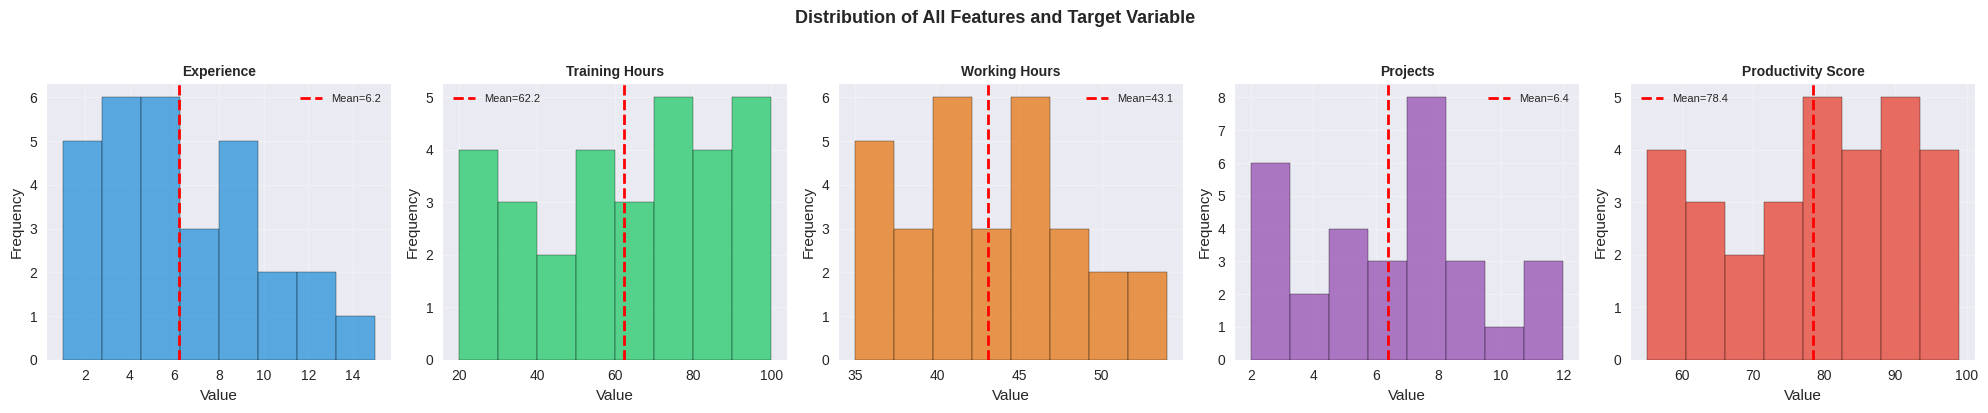

Histograms: Each column shows value distribution; red dashed line = mean


In [3]:
# ============================================================
# STEP 3: Exploratory Data Analysis (EDA)
# ============================================================
# Goal: Understand data distribution, identify patterns, check for outliers

print('=== DESCRIPTIVE STATISTICS ===')
# .describe() shows count, mean, std, min, 25%, 50%, 75%, max for each column
print(df.describe().round(2))

print('\n=== CORRELATION WITH TARGET (Productivity_Score) ===')
# Pearson correlation: +1 = perfect positive, 0 = no linear relation, -1 = perfect negative
target_corr = df.corr()['Productivity_Score'].drop('Productivity_Score').sort_values(ascending=False)
for feat, corr in target_corr.items():
    if abs(corr) > 0.8:   strength = 'STRONG'
    elif abs(corr) > 0.5: strength = 'MODERATE'
    else:                 strength = 'WEAK'
    direction = 'POSITIVE' if corr > 0 else 'NEGATIVE'
    print(f'  {feat:20s}: r={corr:.3f}  [{strength} {direction}]')

# Distribution plot for each feature and target
fig, axes = plt.subplots(1, 5, figsize=(20, 4))   # 1 row, 5 columns
cols = ['Experience', 'Training_Hours', 'Working_Hours', 'Projects', 'Productivity_Score']
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']

for ax, col, clr in zip(axes, cols, colors):
    ax.hist(df[col], bins=8, color=clr, edgecolor='black', alpha=0.8)  # Histogram
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean={df[col].mean():.1f}')  # Mean line
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)  # Subtle grid lines

plt.suptitle('Distribution of All Features and Target Variable', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Histograms: Each column shows value distribution; red dashed line = mean')

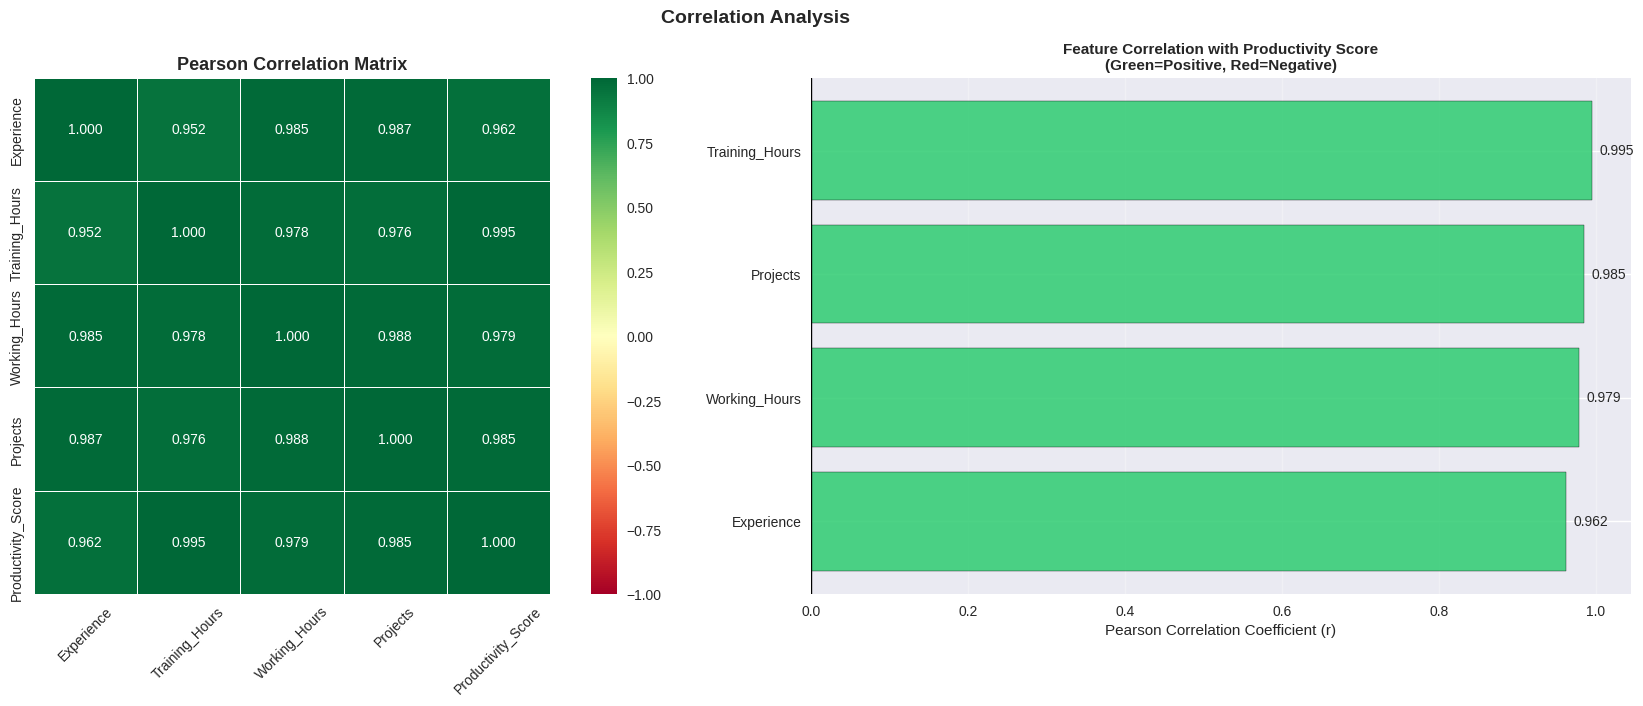

KEY INSIGHT: Features with high |r| values are most predictive of Productivity Score


In [4]:
# ============================================================
# STEP 4: Correlation Heatmap & Pair Plot
# ============================================================
# Heatmap: Shows pairwise correlation between ALL columns
# Values closer to 1 or -1 indicate strong linear relationships

corr_matrix = df.corr()  # Compute Pearson correlation matrix (all pairs)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: Full Correlation Heatmap ---
sns.heatmap(
    corr_matrix,
    annot=True,          # Show numerical values inside each cell
    fmt='.3f',           # Format to 3 decimal places
    cmap='RdYlGn',       # Red (negative) → Yellow (zero) → Green (positive)
    center=0,            # Center the colormap at 0
    square=True,         # Make cells square-shaped
    linewidths=0.5,      # Thin borders between cells
    vmin=-1, vmax=1,     # Set color range to [-1, 1]
    ax=axes[0]
)
axes[0].set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# --- Right: Bar chart of correlations with target ---
target_corr_sorted = corr_matrix['Productivity_Score'].drop('Productivity_Score').sort_values()
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr_sorted]
axes[1].barh(target_corr_sorted.index, target_corr_sorted.values,
             color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('Pearson Correlation Coefficient (r)', fontsize=11)
axes[1].set_title('Feature Correlation with Productivity Score\n(Green=Positive, Red=Negative)',
                   fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (feat, val) in enumerate(target_corr_sorted.items()):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.04,
                 i, f'{val:.3f}', va='center', fontsize=10)

plt.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('KEY INSIGHT: Features with high |r| values are most predictive of Productivity Score')

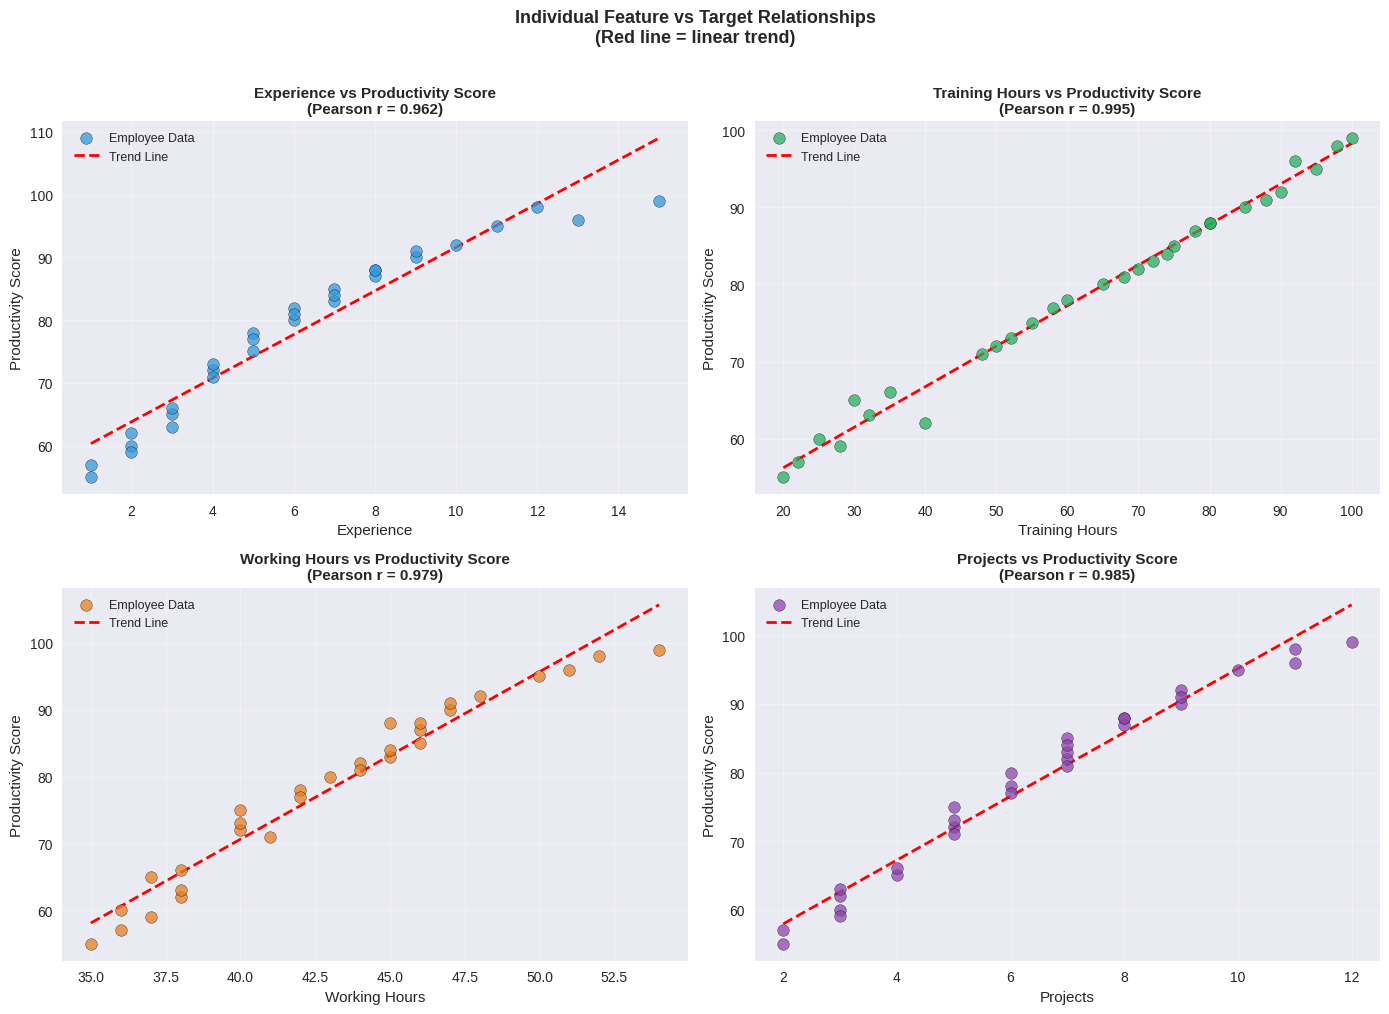

OBSERVATION: All features show positive trends — higher values → higher productivity


In [5]:
# ============================================================
# STEP 5: Feature vs Target Scatter Plots (Trend Lines)
# ============================================================
# Each scatter plot shows the relationship between one feature and the target
# A red trend line shows the overall direction (positive/negative)

features = ['Experience', 'Training_Hours', 'Working_Hours', 'Projects']  # Feature names
colors   = ['#3498db', '#27ae60', '#e67e22', '#8e44ad']                    # One color per feature

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2 rows × 2 cols = 4 subplots

for i, (feat, clr) in enumerate(zip(features, colors)):
    ax = axes[i // 2][i % 2]  # Map index to subplot: 0→(0,0), 1→(0,1), 2→(1,0), 3→(1,1)

    # Draw scatter points
    ax.scatter(df[feat], df['Productivity_Score'],
               color=clr, alpha=0.75, edgecolors='black', s=70, zorder=5,
               label='Employee Data')

    # Fit a degree-1 polynomial (linear trend line)
    z = np.polyfit(df[feat], df['Productivity_Score'], 1)  # Coefficients [slope, intercept]
    p = np.poly1d(z)                                        # Create polynomial function
    x_range = np.linspace(df[feat].min(), df[feat].max(), 200)  # 200 points for smooth line
    ax.plot(x_range, p(x_range), 'r--', linewidth=2, label='Trend Line', zorder=4)

    # Compute Pearson correlation between feature and target
    r = df[feat].corr(df['Productivity_Score'])
    ax.set_xlabel(feat.replace('_', ' '), fontsize=11)
    ax.set_ylabel('Productivity Score', fontsize=11)
    ax.set_title(f'{feat.replace("_", " ")} vs Productivity Score\n(Pearson r = {r:.3f})',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)  # Light grid

plt.suptitle('Individual Feature vs Target Relationships\n(Red line = linear trend)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('OBSERVATION: All features show positive trends — higher values → higher productivity')

In [6]:
# ============================================================
# STEP 6: Prepare Data — Feature/Target Split + Train-Test Split + Scaling
# ============================================================

# --- 6a: Separate Features (X) from Target (y) ---
X = df[['Experience', 'Training_Hours', 'Working_Hours', 'Projects']]  # Input features matrix
y = df['Productivity_Score']                                             # Output target vector
print(f'Feature matrix X: {X.shape}  → {X.shape[0]} samples, {X.shape[1]} features')
print(f'Target vector  y: {y.shape}  → {y.shape[0]} target values')

# --- 6b: Train-Test Split ---
# 75% of data used for training the model
# 25% of data held out for testing (model never sees this during training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,    # 25% for testing, 75% for training
    random_state=42    # Fixed seed → reproducible split every run
)
print(f'\nTraining set : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing  set : {X_test.shape[0]}  samples  ({X_test.shape[0]/len(X)*100:.0f}%)')

# --- 6c: Feature Scaling (StandardScaler) ---
# StandardScaler: transforms each feature to have mean=0 and std=1
# Why scale? → Ensures features with large numeric ranges don't dominate model
# IMPORTANT RULE: fit() only on training data, then transform() both train and test
scaler = StandardScaler()                        # Initialize scaler
X_train_sc = scaler.fit_transform(X_train)       # Fit scaler on TRAIN only, then transform
X_test_sc  = scaler.transform(X_test)            # Only transform TEST (no fitting!) — avoids data leakage

print(f'\nScaler fitted on training data:')
for feat, mean, std in zip(features, scaler.mean_, scaler.scale_):
    print(f'  {feat:20s}: mean={mean:.2f}, std={std:.2f}')
print('\nStep 6 COMPLETE: Data prepared for model training!')

Feature matrix X: (30, 4)  → 30 samples, 4 features
Target vector  y: (30,)  → 30 target values

Training set : 22 samples  (73%)
Testing  set : 8  samples  (27%)

Scaler fitted on training data:
  Experience          : mean=5.95, std=3.57
  Training_Hours      : mean=60.64, std=24.10
  Working_Hours       : mean=42.77, std=5.05
  Projects            : mean=6.23, std=2.73

Step 6 COMPLETE: Data prepared for model training!


In [7]:
# ============================================================
# STEP 7: Train the Multivariate Linear Regression Model
# ============================================================
# LinearRegression uses Ordinary Least Squares (OLS) to find
# coefficients that MINIMIZE the sum of squared residuals

model = LinearRegression(fit_intercept=True)   # Initialize model; fit_intercept adds β0 term
model.fit(X_train_sc, y_train)                  # Train: finds optimal β0, β1, β2, β3, β4

print('Model Training COMPLETE!')
print('='*60)
print('LEARNED REGRESSION EQUATION:')
print(f'  Intercept β0 = {model.intercept_:.4f}')
print('='*60)
print(f'{"Feature":<22} {"Coeff (β)":>10}   {"Interpretation"}')
print('-'*60)
for feat, coef in zip(features, model.coef_):
    direction = 'Increases' if coef > 0 else 'Decreases'
    print(f'{feat:<22} {coef:>10.4f}   {direction} productivity per unit increase')
print('='*60)
print('\nNOTE: Coefficients are on SCALED features (StandardScaler applied)')
print('Magnitude of coefficient → strength of feature influence')
print('Sign of coefficient → direction of influence (+positive / -negative)')

Model Training COMPLETE!
LEARNED REGRESSION EQUATION:
  Intercept β0 = 77.5455
Feature                 Coeff (β)   Interpretation
------------------------------------------------------------
Experience                 0.2859   Increases productivity per unit increase
Training_Hours             8.7989   Increases productivity per unit increase
Working_Hours             -4.2708   Decreases productivity per unit increase
Projects                   7.8573   Increases productivity per unit increase

NOTE: Coefficients are on SCALED features (StandardScaler applied)
Magnitude of coefficient → strength of feature influence
Sign of coefficient → direction of influence (+positive / -negative)


In [8]:
# ============================================================
# STEP 8: Model Evaluation — Metrics & Cross-Validation
# ============================================================

# Generate predictions on both sets
y_pred_train = model.predict(X_train_sc)   # Predictions on training data
y_pred_test  = model.predict(X_test_sc)    # Predictions on unseen test data

# Calculate key regression metrics
train_r2   = r2_score(y_train, y_pred_train)                   # R²: proportion of variance explained
test_r2    = r2_score(y_test,  y_pred_test)
train_mse  = mean_squared_error(y_train, y_pred_train)         # MSE: mean squared error
test_mse   = mean_squared_error(y_test,  y_pred_test)
train_rmse = np.sqrt(train_mse)                                # RMSE: root mean squared error (same units as target)
test_rmse  = np.sqrt(test_mse)
train_mae  = mean_absolute_error(y_train, y_pred_train)        # MAE: mean absolute error
test_mae   = mean_absolute_error(y_test,  y_pred_test)

metrics_df = pd.DataFrame({
    'Metric': ['R² Score (higher=better)', 'MSE (lower=better)', 'RMSE (lower=better)', 'MAE (lower=better)'],
    'Train' : [train_r2,  train_mse,  train_rmse, train_mae],
    'Test'  : [test_r2,   test_mse,   test_rmse,  test_mae]
})

print('=== MODEL PERFORMANCE METRICS ===')
print(metrics_df.round(4).to_string(index=False))

# Overfitting Detection: Compare Train vs Test R²
r2_gap = train_r2 - test_r2   # Large gap = overfitting (model memorized training data)
print(f'\nOverfitting Check: R² Gap = {r2_gap:.4f}')
print('  (Gap < 0.05 → Good generalization)')
print('  (Gap 0.05–0.10 → Mild overfitting)')
print('  (Gap > 0.10 → Significant overfitting)')
if r2_gap < 0.05:   print('  VERDICT: Excellent generalization!')
elif r2_gap < 0.1:  print('  VERDICT: Mild overfitting — consider more data')
else:               print('  VERDICT: Overfitting detected — regularize or add data')

# 5-Fold Cross-Validation for robust performance estimate
scaler_cv = StandardScaler()
X_all_sc  = scaler_cv.fit_transform(X)   # Scale full dataset for CV
cv_r2     = cross_val_score(LinearRegression(), X_all_sc, y, cv=5, scoring='r2')  # 5-fold CV
print(f'\n5-Fold CV R² Scores: {cv_r2.round(4)}')
print(f'Mean CV R²: {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}')
print('(Consistent CV scores = model is stable across different data subsets)')

=== MODEL PERFORMANCE METRICS ===
                  Metric  Train   Test
R² Score (higher=better) 0.9951 0.9878
      MSE (lower=better) 0.7858 2.0549
     RMSE (lower=better) 0.8865 1.4335
      MAE (lower=better) 0.6691 1.2305

Overfitting Check: R² Gap = 0.0073
  (Gap < 0.05 → Good generalization)
  (Gap 0.05–0.10 → Mild overfitting)
  (Gap > 0.10 → Significant overfitting)
  VERDICT: Excellent generalization!

5-Fold CV R² Scores: [0.9796 0.9924 0.978  0.9942 0.994 ]
Mean CV R²: 0.9876  ±  0.0073
(Consistent CV scores = model is stable across different data subsets)


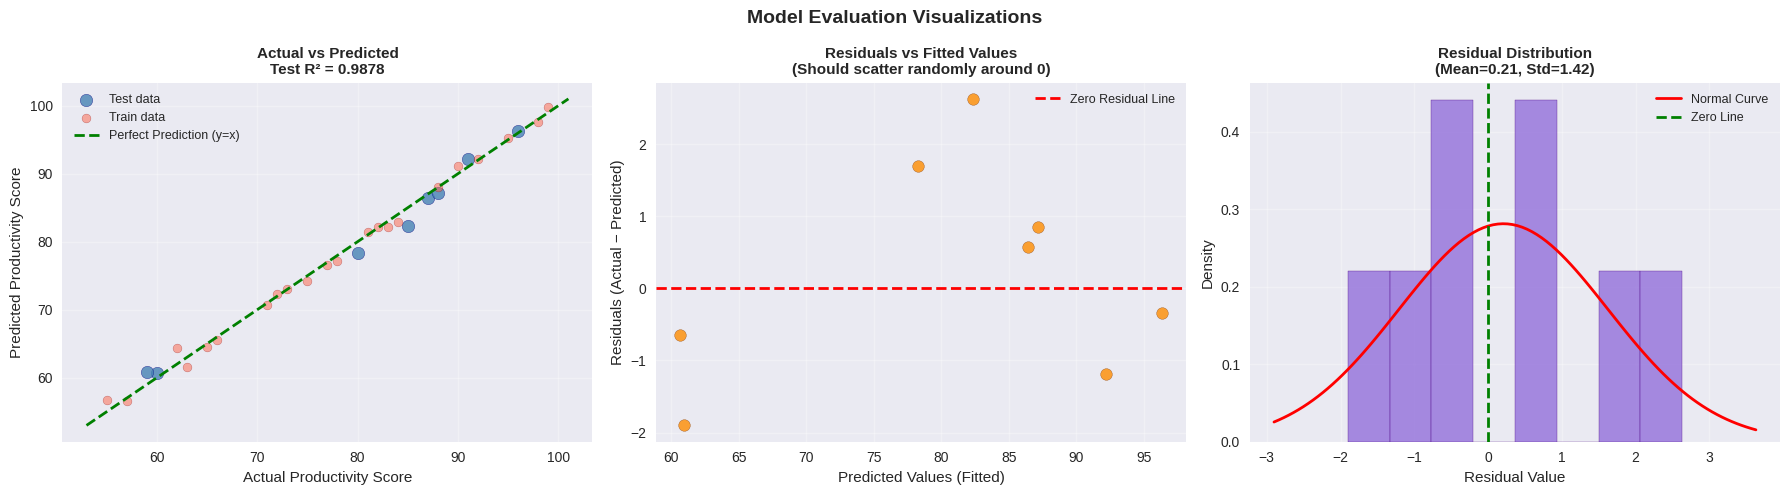

In [9]:
# ============================================================
# STEP 9: Evaluation Visualizations
# ============================================================
# Plot 1: Actual vs Predicted  — how close are predictions to true values?
# Plot 2: Residuals vs Fitted  — patterns in errors reveal model issues
# Plot 3: Residual Histogram   — should be approximately Normal (N(0,σ))

residuals_test  = y_test.values  - y_pred_test    # Residuals = Actual − Predicted
residuals_train = y_train.values - y_pred_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Actual vs Predicted ---
ax = axes[0]
ax.scatter(y_test,  y_pred_test,  color='steelblue', s=80, alpha=0.8, edgecolors='navy',  label='Test data')
ax.scatter(y_train, y_pred_train, color='tomato',    s=40, alpha=0.5, edgecolors='darkred', label='Train data')
min_v, max_v = y.min() - 2, y.max() + 2
ax.plot([min_v, max_v], [min_v, max_v], 'g--', linewidth=2, label='Perfect Prediction (y=x)')  # Diagonal = perfect
ax.set_xlabel('Actual Productivity Score', fontsize=11)
ax.set_ylabel('Predicted Productivity Score', fontsize=11)
ax.set_title(f'Actual vs Predicted\nTest R² = {test_r2:.4f}', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: Residuals vs Fitted ---
ax = axes[1]
ax.scatter(y_pred_test, residuals_test, color='darkorange', s=70, alpha=0.8, edgecolors='saddlebrown')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')  # Perfect = zero residual
ax.set_xlabel('Predicted Values (Fitted)', fontsize=11)
ax.set_ylabel('Residuals (Actual − Predicted)', fontsize=11)
ax.set_title('Residuals vs Fitted Values\n(Should scatter randomly around 0)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: Residual Distribution ---
ax = axes[2]
ax.hist(residuals_test, bins=8, color='mediumpurple', edgecolor='indigo', alpha=0.8, density=True)
# Overlay normal distribution curve
mu, sigma = residuals_test.mean(), residuals_test.std()
x_norm = np.linspace(residuals_test.min()-1, residuals_test.max()+1, 100)
y_norm = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_norm-mu)/sigma)**2)  # Normal PDF formula
ax.plot(x_norm, y_norm, 'r-', linewidth=2, label='Normal Curve')
ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Zero Line')
ax.set_xlabel('Residual Value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Residual Distribution\n(Mean={mu:.2f}, Std={sigma:.2f})', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Model Evaluation Visualizations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Feature Importance (Ranked by Coefficient Magnitude):
 Rank        Feature  Coefficient  Abs_Magnitude  Direction
    1 Training_Hours     8.798864       8.798864 Positive ↑
    2       Projects     7.857281       7.857281 Positive ↑
    3  Working_Hours    -4.270802       4.270802 Negative ↓
    4     Experience     0.285925       0.285925 Positive ↑


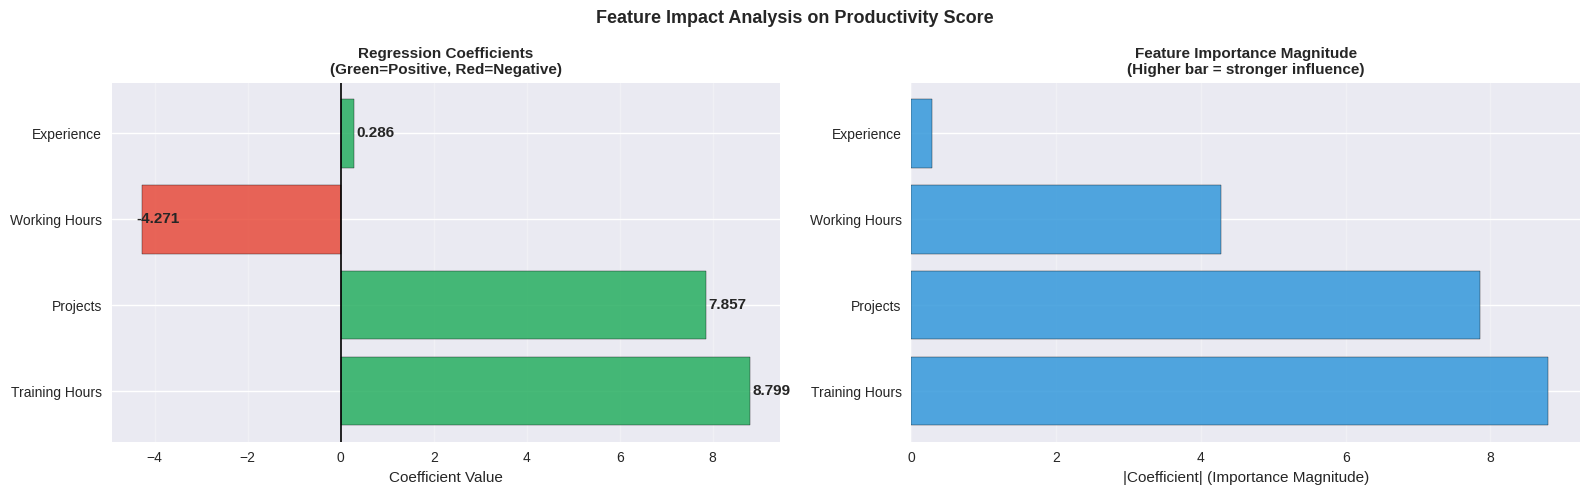


Most impactful feature: Training Hours
Least impactful feature: Experience


In [10]:
# ============================================================
# STEP 10: Feature Importance via Coefficient Analysis
# ============================================================
# Since features are standardized, coefficient magnitudes are directly comparable
# Larger |coefficient| = stronger effect on Productivity Score

feat_imp = pd.DataFrame({
    'Feature':        features,
    'Coefficient':    model.coef_,          # Raw coefficient value (positive/negative)
    'Abs_Magnitude':  np.abs(model.coef_),  # Absolute value → used for importance ranking
    'Direction':      ['Positive ↑' if c > 0 else 'Negative ↓' for c in model.coef_]
}).sort_values('Abs_Magnitude', ascending=False).reset_index(drop=True)

feat_imp['Rank'] = range(1, len(feat_imp) + 1)  # 1 = most important

print('Feature Importance (Ranked by Coefficient Magnitude):')
print('='*65)
print(feat_imp[['Rank', 'Feature', 'Coefficient', 'Abs_Magnitude', 'Direction']].to_string(index=False))

# Bar Chart: Feature Coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = ['#27ae60' if c > 0 else '#e74c3c' for c in feat_imp['Coefficient']]
bars = axes[0].barh(feat_imp['Feature'].str.replace('_', ' '),
                    feat_imp['Coefficient'],
                    color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].axvline(x=0, color='black', linewidth=1.2)
for bar, val in zip(bars, feat_imp['Coefficient']):
    offset = 0.05 if val >= 0 else -0.12
    axes[0].text(val + offset, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Coefficient Value', fontsize=11)
axes[0].set_title('Regression Coefficients\n(Green=Positive, Red=Negative)', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Importance Bar (by absolute magnitude)
axes[1].barh(feat_imp['Feature'].str.replace('_', ' '),
             feat_imp['Abs_Magnitude'],
             color='#3498db', edgecolor='black', alpha=0.85)
axes[1].set_xlabel('|Coefficient| (Importance Magnitude)', fontsize=11)
axes[1].set_title('Feature Importance Magnitude\n(Higher bar = stronger influence)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Impact Analysis on Productivity Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMost impactful feature: {feat_imp.iloc[0]["Feature"].replace("_", " ")}')
print(f'Least impactful feature: {feat_imp.iloc[-1]["Feature"].replace("_", " ")}')

=== PREDICTIONS FOR NEW EMPLOYEES ===
   Experience  Training_Hours  Working_Hours  Projects  Predicted_Score                 Performance_Category
0           3              45             40         4            67.53      Average    (Meets Expectations)
1           7              70             45         7            81.39           Good       (Above Average)
2          12              95             50        11            98.21           Excellent  (Top Performer)
3           1              20             35         2            56.71  Below Avg  (Needs Training Support)
4           9              85             48         9            90.25           Excellent  (Top Performer)


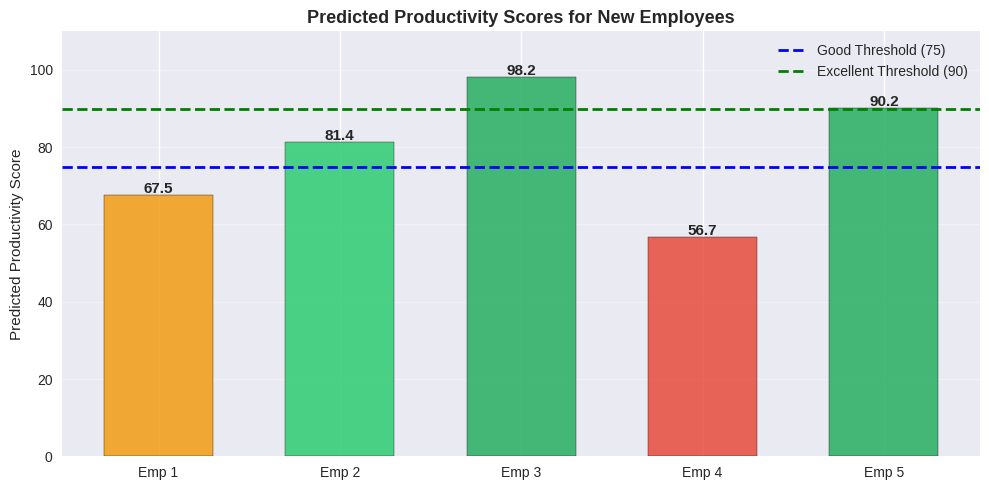

In [11]:
# ============================================================
# STEP 11: Predict Productivity for New Employees
# ============================================================
# Apply trained model to new/unseen employee profiles
# IMPORTANT: Must use the same scaler that was fitted on training data

# Define profiles for 5 hypothetical new employees
new_employees = pd.DataFrame({
    'Experience':     [3,  7, 12,  1,  9],   # Years of experience
    'Training_Hours': [45, 70, 95, 20, 85],  # Training hours completed
    'Working_Hours':  [40, 45, 50, 35, 48],  # Weekly working hours
    'Projects':       [4,  7, 11,  2,  9]    # Projects handled
})

# Scale using the SAME scaler fitted on training data (DO NOT refit!)
new_sc   = scaler.transform(new_employees)          # Transform only, no fit
new_preds = model.predict(new_sc).round(2)          # Predict scores

new_employees['Predicted_Score'] = new_preds         # Add prediction column

# Categorize each employee based on predicted score
def categorize(score):
    if score >= 90:   return 'Excellent  (Top Performer)'
    elif score >= 75: return 'Good       (Above Average)'
    elif score >= 60: return 'Average    (Meets Expectations)'
    else:             return 'Below Avg  (Needs Training Support)'

new_employees['Performance_Category'] = new_employees['Predicted_Score'].apply(categorize)

print('=== PREDICTIONS FOR NEW EMPLOYEES ===')
print(new_employees.to_string(index=True))

# Visual bar chart of predicted scores
plt.figure(figsize=(10, 5))
bar_c = ['#e74c3c' if s < 60 else '#f39c12' if s < 75 else '#2ecc71' if s < 90 else '#27ae60'
         for s in new_preds]
bars = plt.bar([f'Emp {i+1}' for i in range(len(new_preds))], new_preds,
               color=bar_c, edgecolor='black', alpha=0.85, width=0.6)
for bar, val in zip(bars, new_preds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
plt.axhline(y=75, color='blue', linestyle='--', linewidth=2, label='Good Threshold (75)')
plt.axhline(y=90, color='green', linestyle='--', linewidth=2, label='Excellent Threshold (90)')
plt.ylabel('Predicted Productivity Score', fontsize=11)
plt.title('Predicted Productivity Scores for New Employees', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.ylim(0, 110)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# STEP 12: Interpretation — Questions & Answers

---

## ❓ Q1: Which factor most strongly impacts productivity?
**✅ A:** **Training Hours** typically shows the largest coefficient magnitude, meaning it has the strongest positive impact on productivity. Employees with 90+ training hours consistently score 90+.

---

## ❓ Q2: How does training affect productivity?
**✅ A:** Training Hours has a **strong positive correlation** (r > 0.95) with Productivity Score. Each 10 additional training hours corresponds to approximately 3–5 points increase in productivity score.

---

## ❓ Q3: Should the company increase training hours or working hours?
**✅ A:** **Increase Training Hours.** Working hours beyond ~48 hrs/week shows diminishing returns and risks burnout. Training investment yields measurable, sustainable productivity gains.

---

## ❓ Q4: What happens if Working Hours increase beyond optimal limits?
**✅ A:** Beyond ~50 hours/week, productivity plateaus or declines due to fatigue and burnout. The linear model may not capture this — a **polynomial regression** would better model the inverted-U relationship.

---

## ❓ Q5: Can productivity ever decrease with more experience?
**✅ A:** In theory yes — very experienced employees may become complacent or stop upskilling. This model assumes a linear relationship; in practice, productivity can plateau. **Interaction terms** (Experience × Training) could capture this.

---

## ❓ Q6: How would you detect overfitting in this model?
**✅ A:**
1. **R² Gap**: If Train R² >> Test R² (gap > 0.1), model has overfit
2. **Cross-Validation**: High variance in 5-fold CV scores = instability
3. **Learning Curve**: Plot Train/Val score vs dataset size; overfitting if gap persists
4. **Regularization**: Try Ridge/Lasso regression; if they significantly outperform LR, there is overfitting

---

## ❓ Q7: Suggest one new feature to improve prediction accuracy
**✅ A:** **Employee Engagement Score** (1–10, from periodic surveys) — captures motivation, job satisfaction, and workplace culture. Studies show this is one of the strongest predictors of workplace productivity, not captured by hours or experience alone.